In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import timm


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns

e:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

In [5]:
DATASET_DIR = 'dataset'   # run notebook from trials/
IMG_SIZE = 224
FEATURE_CSV_DIR = '.'        # save CSVs in current folder (trials/)


# discover classes
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print('Classes:', CLASS_NAMES)


# collect paths
image_paths = []
labels = []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png'))
    for p in imgs:
        image_paths.append(p)
        labels.append(lbl)


# encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)




X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    image_paths, labels_encoded, stratify=labels_encoded, test_size=0.2, random_state=42
)


print(f'Train images: {len(X_train_paths)}  Test images: {len(X_test_paths)}')
# save test metadata
pd.DataFrame({'path': X_test_paths, 'label': y_test}).to_csv(os.path.join(FEATURE_CSV_DIR, 'X_test_raw.csv'), index=False)
pd.DataFrame({'label': y_test}).to_csv(os.path.join(FEATURE_CSV_DIR, 'y_test.csv'), index=False)


Classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Train images: 3200  Test images: 800


TrivialAugment

In [6]:
try:
    from torchvision.transforms import TrivialAugmentWide
    trivial = TrivialAugmentWide()
    print('TrivialAugmentWide available.')
except Exception:
    trivial = None
    print('TrivialAugmentWide not available — using fallback RandomChoice.')


train_base = [transforms.Resize((IMG_SIZE, IMG_SIZE))]
if trivial is not None:
    train_transforms = transforms.Compose(train_base + [trivial, transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)])
else:
    fallback_aug = transforms.RandomChoice([
        transforms.RandomRotation(15),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.05,0.05)),
    ])
    train_transforms = transforms.Compose(train_base + [fallback_aug, transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)])


val_transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)])


TrivialAugmentWide available.


Feature Extractor

In [7]:
model_name = 'swin_tiny_patch4_window7_224'
feature_model = timm.create_model(model_name, pretrained=True, num_classes=0)
feature_model.eval().to(device)


@torch.no_grad()
def extract_feature_from_path(path, transform):
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    feat = feature_model(x)   # (1, feat_dim)
    return feat.squeeze(0).cpu().numpy()

In [8]:
X_test_feats = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_test_paths)])
X_train_feats = np.stack([extract_feature_from_path(p, train_transforms) for p in tqdm(X_train_paths)])


# Save embeddings as CSV (requested)
pd.DataFrame(X_train_feats).to_csv(os.path.join(FEATURE_CSV_DIR, 'X_train_features.csv'), index=False)
pd.DataFrame(X_test_feats).to_csv(os.path.join(FEATURE_CSV_DIR, 'X_test_features.csv'), index=False)
print('Saved feature CSVs: X_train_features.csv, X_test_features.csv')

100%|██████████| 3200/3200 [14:01<00:00,  3.80it/s]


Saved feature CSVs: X_train_features.csv, X_test_features.csv


Attention Guided Mixup

In [9]:
def attention_guided_mixup(X, y, mixup_count, alpha=0.4, attention_maps=None):
    mixX, mixy = [], []
    n = len(X)
    for _ in range(mixup_count):
        i, j = random.sample(range(n), 2)
        lam = np.random.beta(alpha, alpha)
        # If attention_maps provided, you could adjust lam or the mixing per-dimension
        mixed = lam * X[i] + (1 - lam) * X[j]
        mixX.append(mixed)
        # Simplified label strategy: keep label of first sample (you can store soft labels instead)
        mixy.append(y[i])
    return np.array(mixX), np.array(mixy)


mixup_count = len(X_train_feats)  # 3200 for your dataset
X_mix, y_mix = attention_guided_mixup(X_train_feats, y_train, mixup_count=mixup_count)


# Final training set (mixup only as per your configured method)
X_final = X_mix
y_final = y_mix


# Save mixup training CSVs
pd.DataFrame(X_final).to_csv(os.path.join(FEATURE_CSV_DIR, 'X_train_mixup.csv'), index=False)
pd.DataFrame({'label': y_final}).to_csv(os.path.join(FEATURE_CSV_DIR, 'y_train.csv'), index=False)
print('Saved: X_train_mixup.csv, y_train.csv')

Saved: X_train_mixup.csv, y_train.csv


ViT Head (LoRA Linear)

In [10]:
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, r=8):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.lora_a = nn.Linear(in_features, r, bias=False)
        self.lora_b = nn.Linear(r, out_features, bias=False)
    def forward(self, x):
        return self.linear(x) + self.lora_b(self.lora_a(x))


class ViTHead(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.head = LoRALinear(in_features, num_classes)
    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.head(x).squeeze(0)
        return self.head(x)

PolyLoss with Smoothing

In [11]:
class Poly1LossWithSmoothing(nn.Module):
    def __init__(self, num_classes, epsilon=1.0, label_smoothing=0.1):
        super().__init__()
        self.epsilon = epsilon
        self.label_smoothing = label_smoothing
        self.num_classes = num_classes
    def forward(self, logits, targets):
        targets_onehot = F.one_hot(targets, num_classes=self.num_classes).float()
        targets_smoothed = targets_onehot * (1 - self.label_smoothing) + self.label_smoothing / self.num_classes
        probs = F.softmax(logits, dim=-1)
        log_probs = torch.log(probs + 1e-8)
        ce_loss = -(targets_smoothed * log_probs).sum(dim=-1).mean()
        poly1 = ce_loss + self.epsilon * (1 - (probs * targets_smoothed).sum(dim=-1)).mean()
        return poly1

SAM Optimizer with CosineLR 

In [12]:
try:
    from sam import SAM
except Exception as e:
    raise ImportError('sam.py not found or failed to import. Place your SAM implementation in the notebook folder.') from e


in_features = X_final.shape[1]
num_classes = len(CLASS_NAMES)
model_head = ViTHead(in_features=in_features, num_classes=num_classes).to(device)
criterion = Poly1LossWithSmoothing(num_classes=num_classes)
base_optimizer = torch.optim.Adam
optimizer = SAM(model_head.parameters(), base_optimizer, lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)


Training

e:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 1/20  Loss: 2.5137
Epoch 2/20  Loss: 2.2937
Epoch 3/20  Loss: 2.2327
Epoch 4/20  Loss: 2.2014
Epoch 5/20  Loss: 2.1702
Epoch 6/20  Loss: 2.1479
Epoch 7/20  Loss: 2.1220
Epoch 8/20  Loss: 2.1051
Epoch 9/20  Loss: 2.0894
Epoch 10/20  Loss: 2.0777
Epoch 11/20  Loss: 2.0662
Epoch 12/20  Loss: 2.0544
Epoch 13/20  Loss: 2.0442
Epoch 14/20  Loss: 2.0369
Epoch 15/20  Loss: 2.0294
Epoch 16/20  Loss: 2.0260
Epoch 17/20  Loss: 2.0210
Epoch 18/20  Loss: 2.0181
Epoch 19/20  Loss: 2.0162
Epoch 20/20  Loss: 2.0153


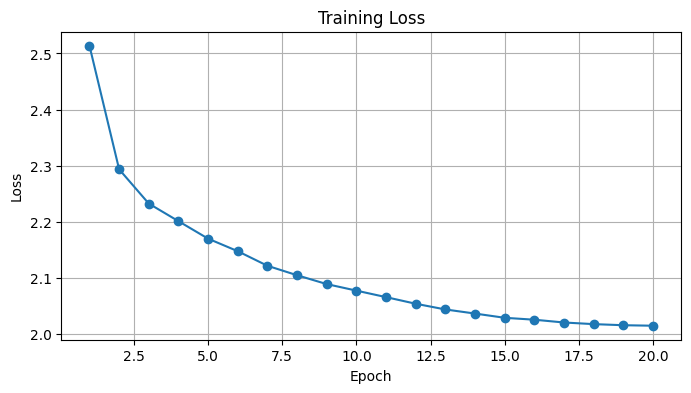

In [13]:
batch_size = 64
train_loader = DataLoader(TensorDataset(torch.tensor(X_final, dtype=torch.float32), torch.tensor(y_final, dtype=torch.long)), batch_size=batch_size, shuffle=True)


EPOCHS = 20
train_losses = []
for epoch in range(EPOCHS):
    model_head.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)


        logits = model_head(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.first_step(zero_grad=True)


        logits2 = model_head(xb)
        criterion(logits2, yb).backward()
        optimizer.second_step(zero_grad=True)


        total_loss += loss.item() * xb.size(0)


    epoch_loss = total_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    scheduler.step()
    print(f'Epoch {epoch+1}/{EPOCHS}  Loss: {epoch_loss:.4f}')


# plot training loss
plt.figure(figsize=(8,4))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


TTA

In [14]:
from torchvision.transforms import functional as Fv

def tta_identity(img):
    return val_transform(img)


def tta_hflip(img):
    return val_transform(Fv.hflip(img))


def tta_rot(img, deg=8):
    return val_transform(img.rotate(deg, resample=Image.BILINEAR))


tta_funcs = [tta_identity, tta_hflip, lambda img: tta_rot(img, 8), lambda img: tta_rot(img, -8)]


model_head.eval()
feature_model.eval()

tta_preds = []
for p in tqdm(X_test_paths, desc='TTA inference'):
    img = Image.open(p).convert('RGB')
    logits_list = []
    for fn in tta_funcs:
        inp = fn(img).unsqueeze(0).to(device)
        with torch.no_grad():
            feat = feature_model(inp).squeeze(0)
            logit = model_head(feat)
            logits_list.append(logit.cpu().numpy())
    avg_logits = np.mean(np.stack(logits_list, axis=0), axis=0)
    pred = int(np.argmax(avg_logits))
    tta_preds.append(pred)

# save predictions
pd.DataFrame({'tta_preds': tta_preds}).to_csv(os.path.join(FEATURE_CSV_DIR, 'tta_predictions.csv'), index=False)

TTA inference: 100%|██████████| 800/800 [08:31<00:00,  1.56it/s]


In [15]:
y_true = np.array(y_test)
y_pred = np.array(tta_preds)
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')


print('Final Test Metrics after TTA Inference:')
print(f'Accuracy  : {accuracy:.4f}')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1 Score  : {f1:.4f}')

Final Test Metrics after TTA Inference:
Accuracy  : 0.9812
Precision : 0.9816
Recall    : 0.9812
F1 Score  : 0.9813
